# Plotting mortality difference due to PM<sub>2.5</sub> exposure between scenarios by country

Using central estimates only

In [1]:
import os
import xarray as xr
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from matplotlib.colors import SymLogNorm
from matplotlib.ticker import FuncFormatter
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from utils.utils import autosize_figure
import config
from utils.utils import require_dir, create_eu_country_map
import pathlib

In [2]:
def get_mortality(scenario, year, GBD_version):
    # === Path config ===
    MORT_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "mortality" / "gridpoint_mortality")

    file = f"Mortality_Country_sum_GBD23_{scenario}_{year}.nc"
    file_path = os.path.join(MORT_DIR, file)
    da = xr.open_dataarray(file_path)

    return da

In [3]:
GBD_version = "GBD23"
scenarios = ["H", "HL", "L", "LN", "M", "ML", "VL"]
scenario_longname = ["High", "High-to-Low", "Low", "Low-to-Negative", "Medium", "Medium-to-Low", "Very Low"]
years = [2040, 2060, 2080, 2100]

## Plotting individual years

In [5]:
def plot_mortality_diff(da, scenario, scen_name, select_scenario, GBD_version, year, SAVE_DIR):
    # Create figure
    fig = plt.figure(figsize=autosize_figure(1, 1, yscale_factor=1.2))
    gs = GridSpec(1, 2, width_ratios=[15, 1])  # rows, columns
    # Map set up and design
    projection = ccrs.EuroPP()
    crs = ccrs.PlateCarree()
    country_borders = cfeature.NaturalEarthFeature(
        category='cultural',
        name='admin_0_boundary_lines_land',
        scale='10m',
        facecolor='none')

    # Symmetric range so zero sits at the center of the colormap
    vabs = max(abs(da.min(skipna=True).item()), abs(da.max(skipna=True).item()))
    linthresh = 1
    cmap = plt.get_cmap("RdBu_r")  # positive (increase vs reference) = red, negative (decrease) = blue
    norm = SymLogNorm(linthresh=linthresh, vmin=-vabs, vmax=vabs, base=10)

    # First panel
    ax = fig.add_subplot(gs[0, 0], projection=projection, frameon=True)
    cb = da.plot(
        ax=ax,
        transform=crs,
        add_colorbar=False,
        cmap=cmap,
        norm=norm,
    )
    ax.add_feature(country_borders, edgecolor='white', alpha=0.5, linewidth=0.75)
    plt.title(f"{scen_name} minus {select_scenario}, {year}")

    # First colorbar
    cax = fig.add_subplot(gs[0, 1])
    col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
    col_bar.set_label("Difference in PM$_{2.5}$ Mortality year$^{-1}$", fontsize=13)

    # Ticks — symmetric, log-spaced on either side of zero
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    candidate_ticks = [-1000, -100, -10, -1, 0, 1, 10, 100, 1000]
    ticks = [t for t in candidate_ticks if -vabs <= t <= vabs]
    col_bar.set_ticks(ticks)
    col_bar.ax.yaxis.set_major_formatter(formatter)

    plt.tight_layout()
    out_file = f"EU_mortality_pm25_diff_per_country_{GBD_version}_{scenario}-{select_scenario}_{year}.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path, dpi=300)
    return

In [6]:
MASKS_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR" / "masks" / "country", "country masks")
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "mortality" / "pm25" / "yearly")

select_scenario = "M"  # chosen comparison scenario

for scenario, scen_name in zip(scenarios, scenario_longname):
    if scenario == select_scenario:
        continue
    for year in years:
        da = get_mortality(scenario, year, GBD_version)
        da_select_scenario = get_mortality(select_scenario, year, GBD_version)
        da_diff = da - da_select_scenario
        # get eu map by country
        da_map = create_eu_country_map(da_diff, MASKS_DIR)
        # Plotting
        plt.rcParams.update({'font.size': 16})
        plot_mortality_diff(da_map, scenario, scen_name, select_scenario, GBD_version, year, SAVE_DIR)
        plt.close()

## Plotting 2x2 per scenario

In [4]:
def plot_mortality_diff_grid(das, scenario, scen_name, select_scenario, GBD_version, years, SAVE_DIR):
    fig = plt.figure(figsize=autosize_figure(2, 2, yscale_factor=1.3))
    # 2 rows x 2 map columns + 1 narrow colorbar column spanning both rows
    gs = GridSpec(2, 3, width_ratios=[15, 15, 1], height_ratios=[1, 1])

    projection = ccrs.EuroPP()
    crs = ccrs.PlateCarree()
    country_borders = cfeature.NaturalEarthFeature(
        category='cultural', name='admin_0_boundary_lines_land',
        scale='10m', facecolor='none')
    cmap = plt.get_cmap("RdBu_r")

    # Shared symmetric scale across all four years — computed once from the global extremes
    vabs = max(
        max(abs(da.min(skipna=True).item()), abs(da.max(skipna=True).item()))
        for da in das
    )
    linthresh = 1
    norm = SymLogNorm(linthresh=linthresh, vmin=-vabs, vmax=vabs, base=10)

    positions = [(0, 0), (0, 1), (1, 0), (1, 1)]
    for (r, c), da, year in zip(positions, das, years):
        ax = fig.add_subplot(gs[r, c], projection=projection, frameon=True)
        cb = da.plot(ax=ax, transform=crs, add_colorbar=False, cmap=cmap, norm=norm)
        ax.add_feature(country_borders, edgecolor='white', alpha=0.5, linewidth=0.75)
        ax.set_title(f"{year}")

    fig.suptitle(f"{scen_name} minus {select_scenario}", y=0.98)

    # Shared colorbar spanning both rows
    cax = fig.add_subplot(gs[:, 2])
    col_bar = plt.colorbar(cb, cax=cax, orientation='vertical')
    col_bar.set_label("Difference in PM$_{2.5}$ Mortality year$^{-1}$", fontsize=16)
    formatter = FuncFormatter(lambda v, _: f"{v:g}")
    candidate_ticks = [-1000, -100, -10, -1, 0, 1, 10, 100, 1000]
    ticks = [t for t in candidate_ticks if -vabs <= t <= vabs]
    col_bar.set_ticks(ticks)
    col_bar.ax.yaxis.set_major_formatter(formatter)

    plt.tight_layout()
    out_file = f"EU_mortality_pm25_diff_per_country_{GBD_version}_{scenario}-{select_scenario}_grid.png"
    out_path = os.path.join(SAVE_DIR, out_file)
    plt.savefig(out_path, dpi=300)

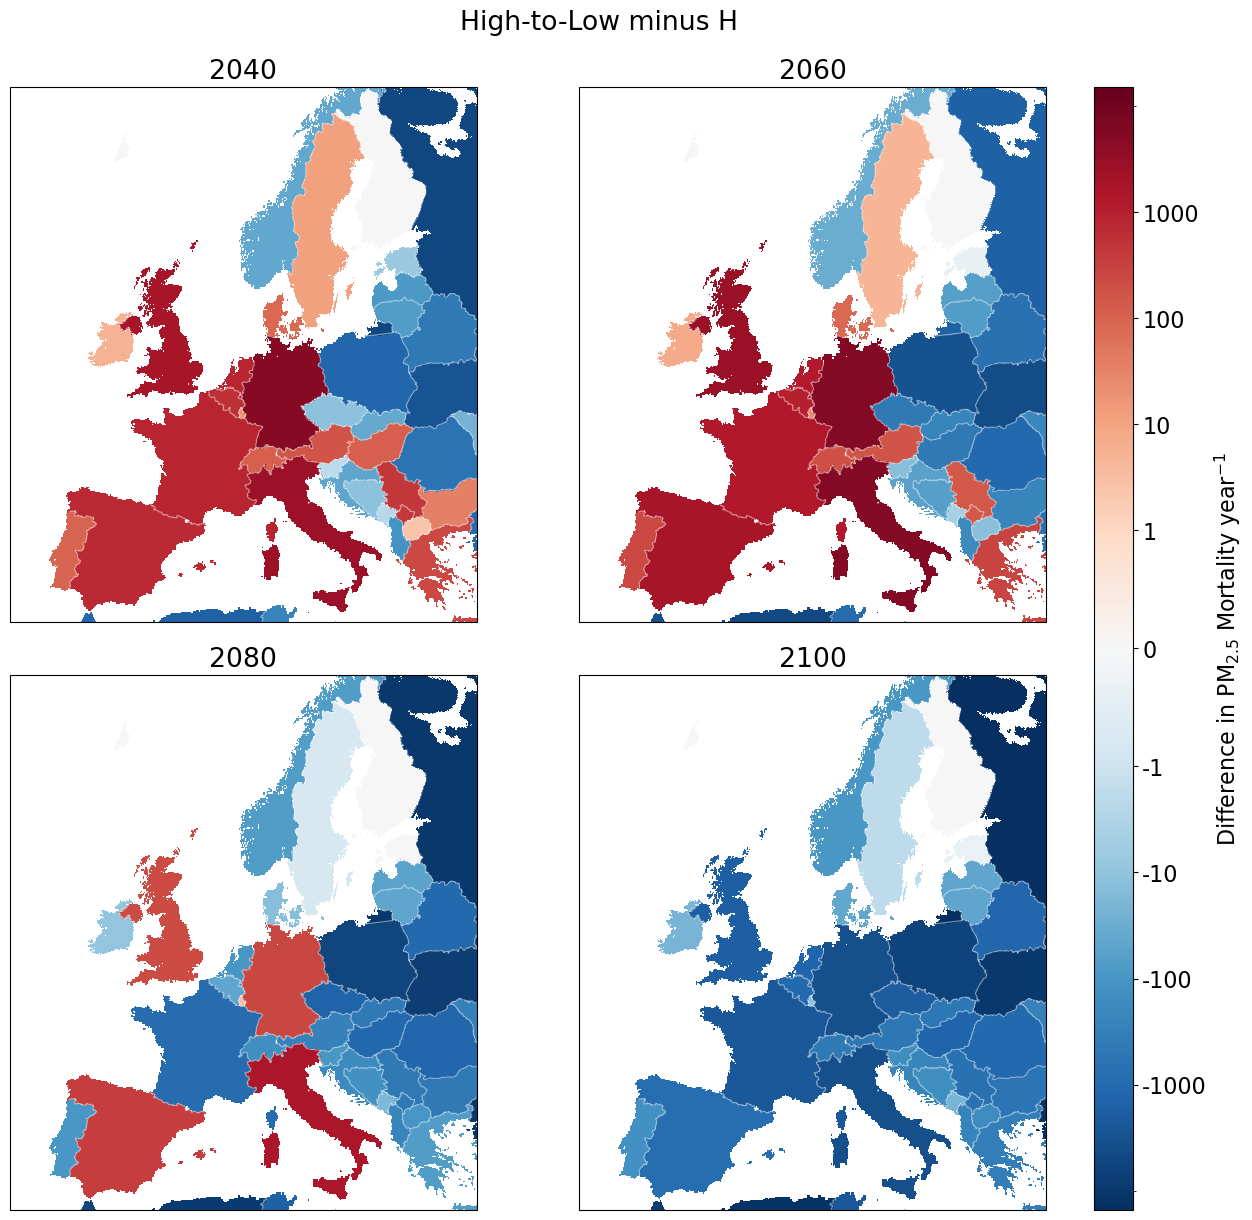

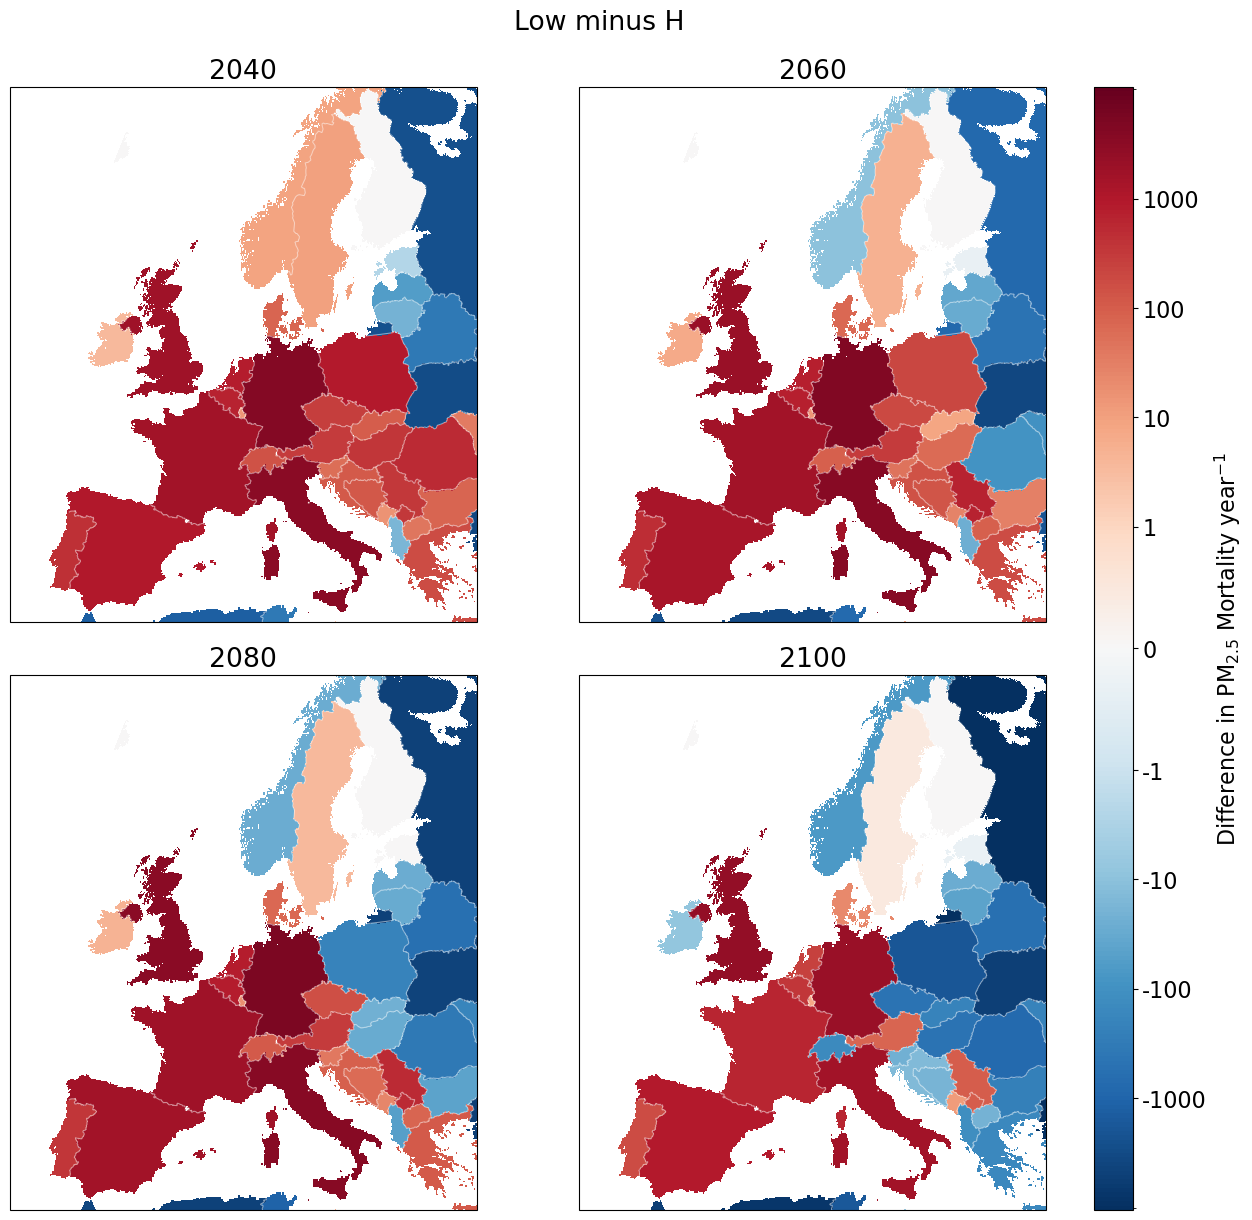

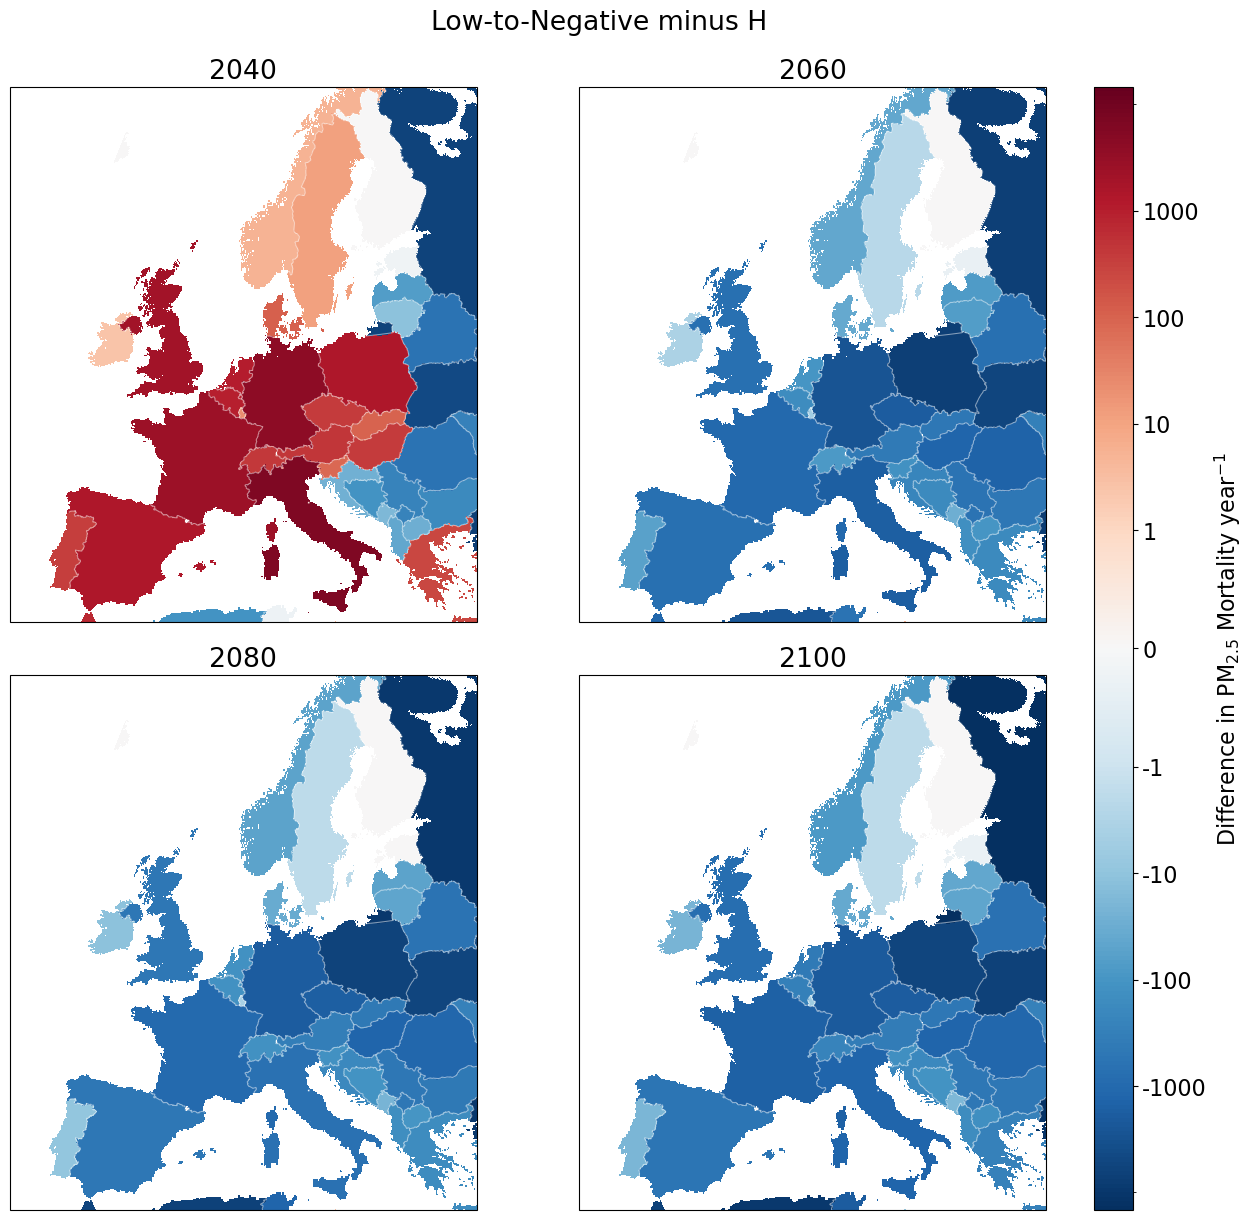

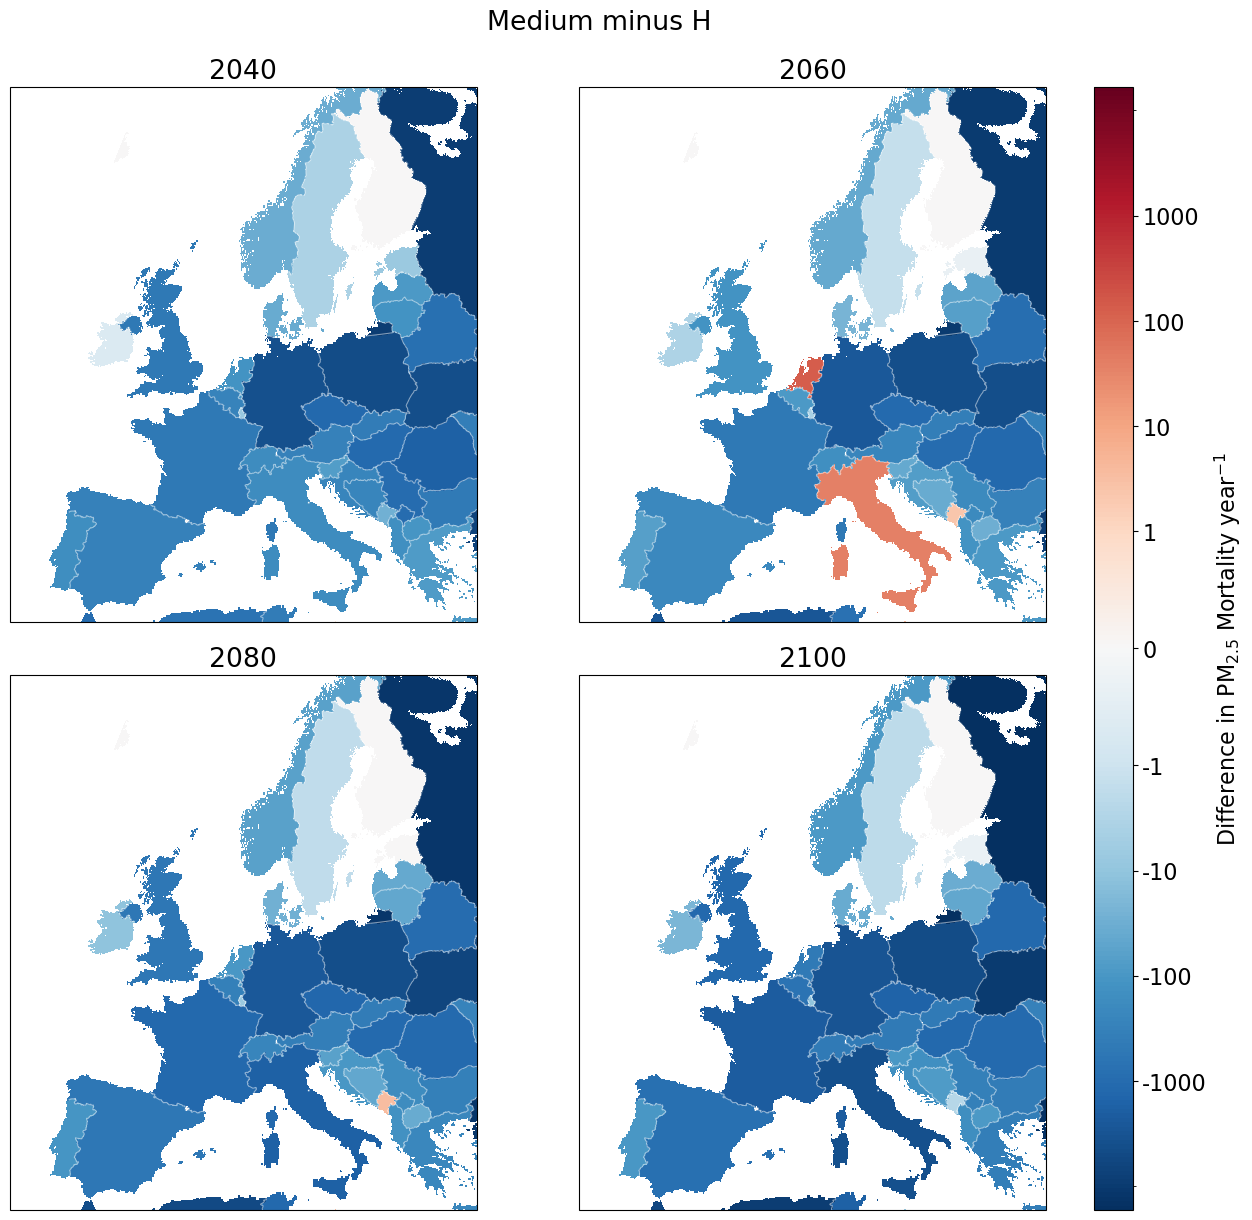

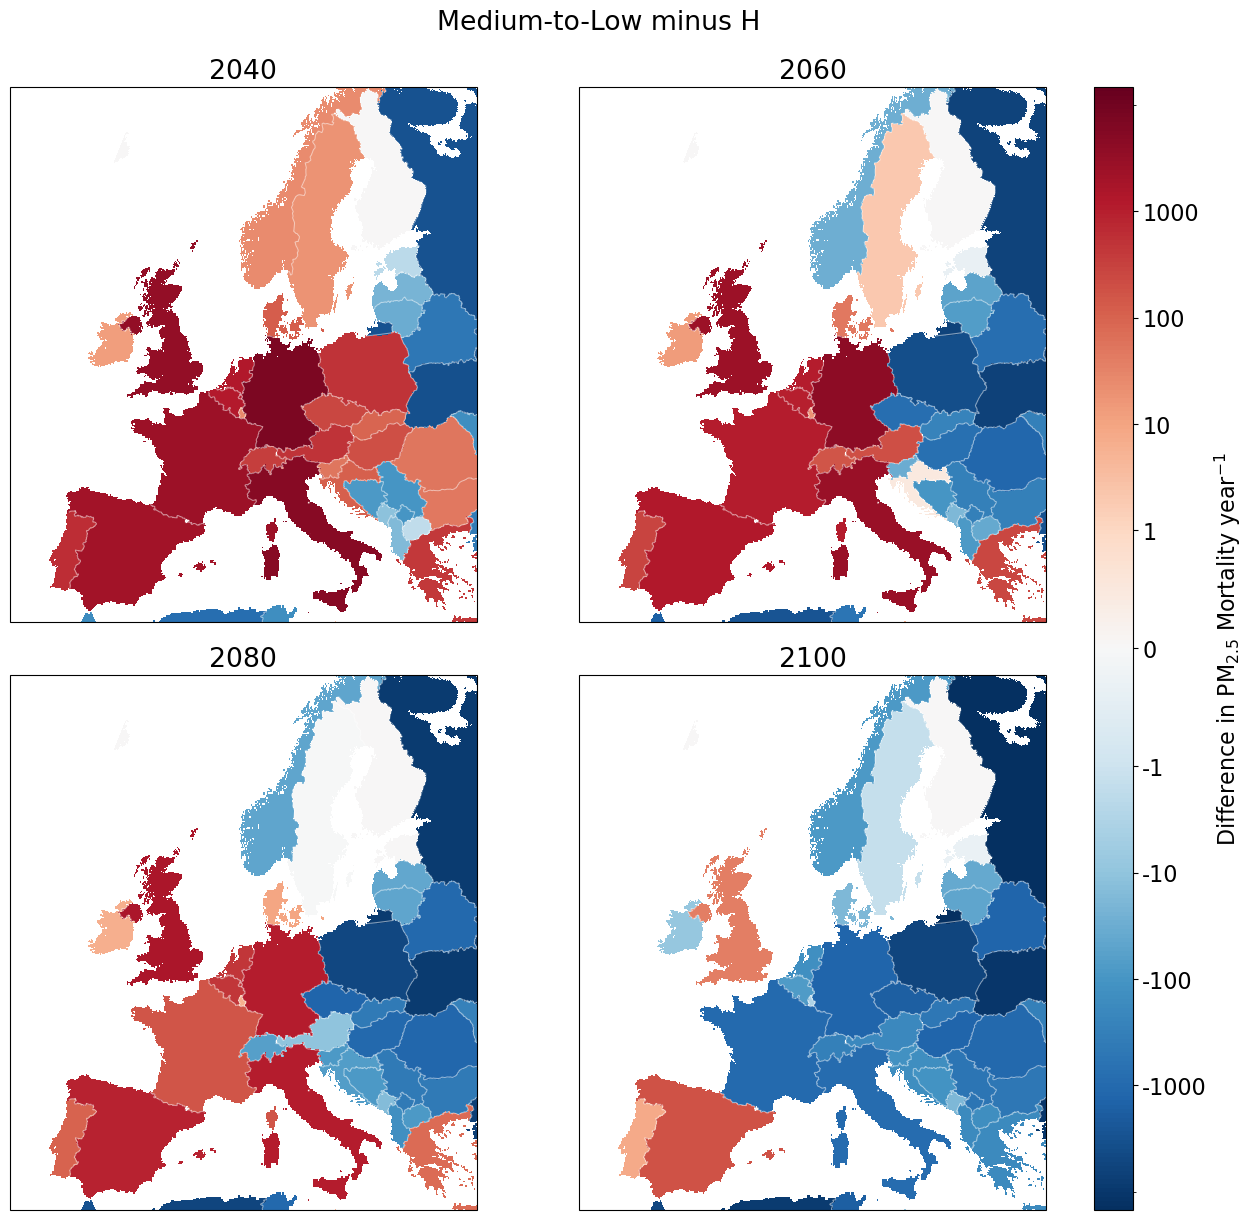

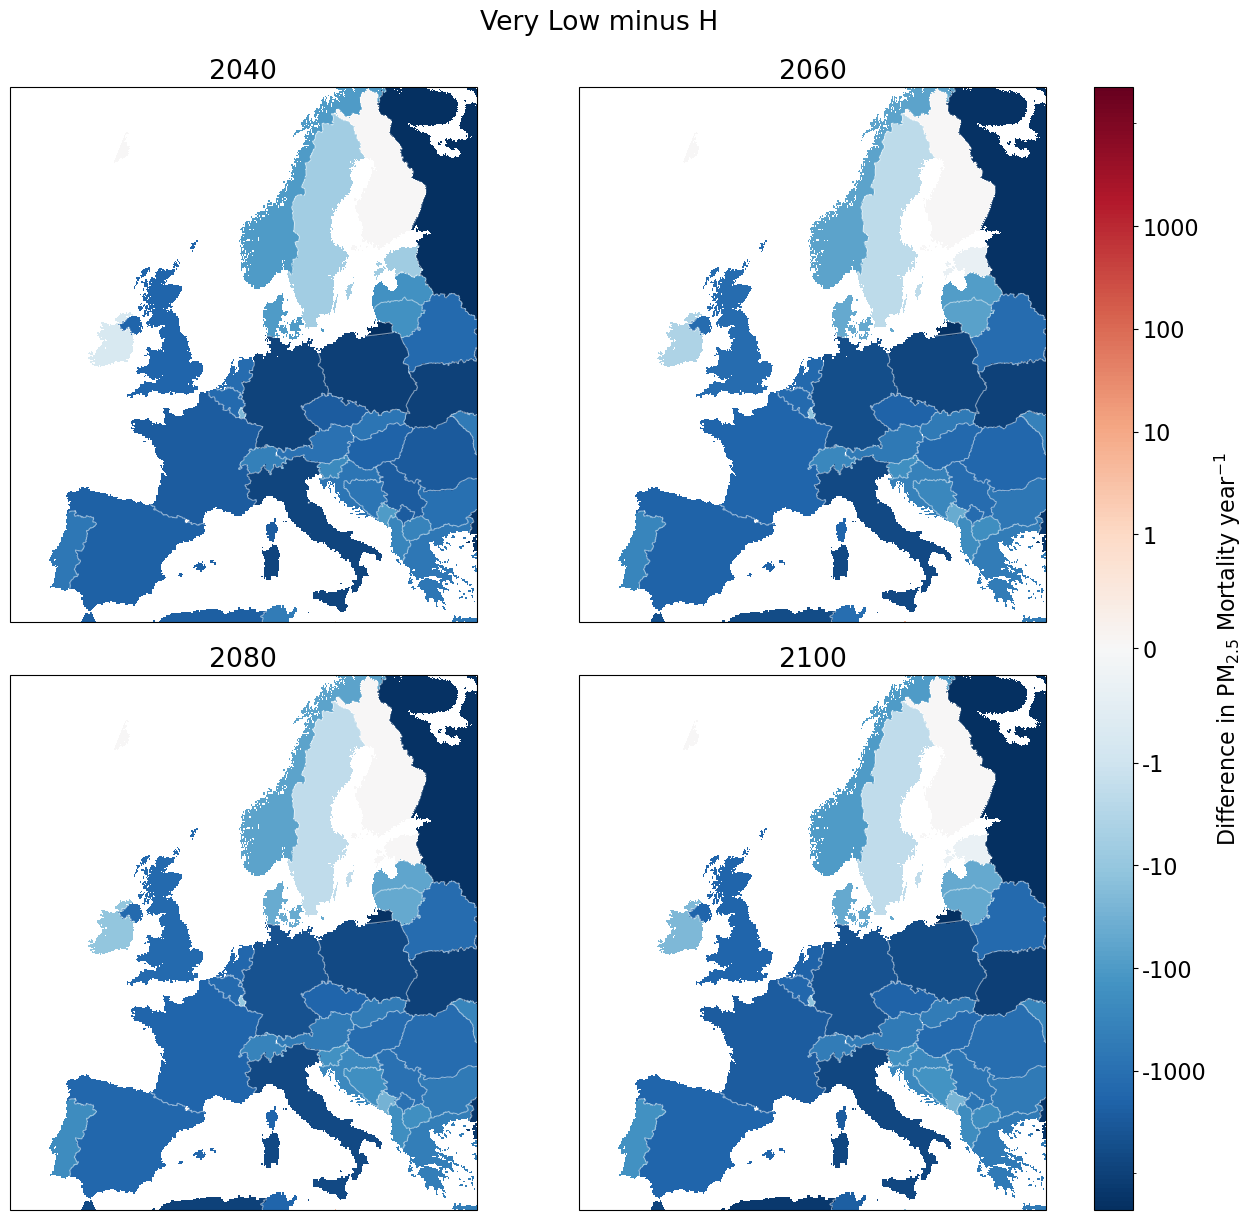

In [6]:
MASKS_DIR = require_dir(pathlib.Path(config.WORK_ROOT) / "BMR" / "masks" / "country", "country masks")
SAVE_DIR = require_dir(pathlib.Path(config.PLOTTING_ROOT) / "mortality" / "pm25" / "scenario")

select_scenario = "H"  # chosen comparison scenario

for scenario, scen_name in zip(scenarios, scenario_longname):
    if scenario == select_scenario:
        continue
    das_diff = [get_mortality(scenario, year, GBD_version) - get_mortality(select_scenario, year, GBD_version) for year in years]
    # convert to eu map
    das_map = [create_eu_country_map(da, MASKS_DIR) for da in das_diff]
    plt.rcParams.update({'font.size': 16})
    plot_mortality_diff_grid(das_map, scenario, scen_name, select_scenario, GBD_version, years, SAVE_DIR)